# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck



In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [23]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

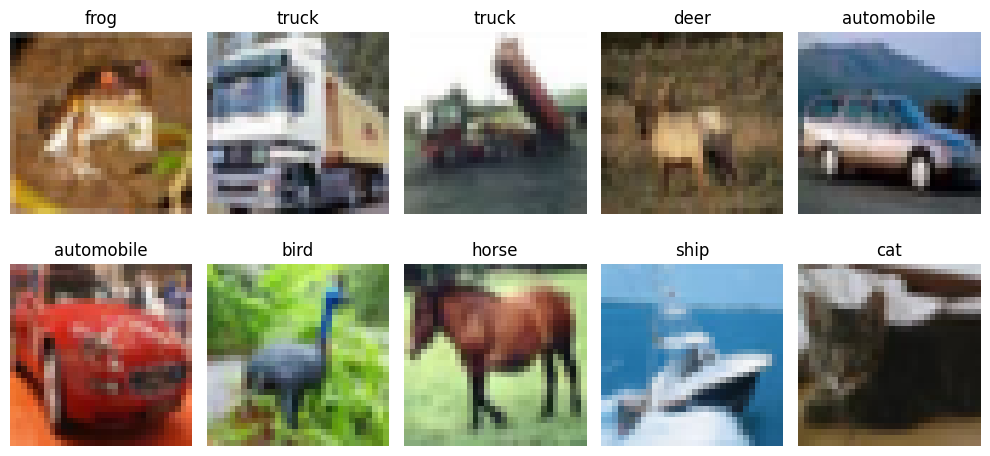

In [24]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [25]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened shape for ANN:", x_train_flat.shape)
print("Normalized shape for CNN:", x_train_norm.shape)

Flattened shape for ANN: (50000, 3072)
Normalized shape for CNN: (50000, 32, 32, 3)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [26]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2662 - loss: 1.9959 - val_accuracy: 0.3376 - val_loss: 1.8523
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3124 - loss: 1.8781 - val_accuracy: 0.3422 - val_loss: 1.8082
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3334 - loss: 1.8215 - val_accuracy: 0.3714 - val_loss: 1.7626
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3452 - loss: 1.7909 - val_accuracy: 0.3590 - val_loss: 1.7748
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3560 - loss: 1.7669 - val_accuracy: 0.3958 - val_loss: 1.6977
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3602 - loss: 1.7546 - val_accuracy: 0.4074 - val_loss: 1.6789
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3696 - loss: 1.7321 - val_accuracy: 0.3984 - val_loss: 1.6977
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3739 - loss: 1.7208 - val_accuracy: 0.

In [27]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4273 - loss: 1.6373
ANN Test Accuracy: 0.42730000615119934


CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [28]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4551 - loss: 1.5158 - val_accuracy: 0.5250 - val_loss: 1.3436
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6017 - loss: 1.1381 - val_accuracy: 0.5944 - val_loss: 1.1547
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6700 - loss: 0.9556 - val_accuracy: 0.6436 - val_loss: 1.0553
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7110 - loss: 0.8331 - val_accuracy: 0.7094 - val_loss: 0.8325
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7422 - loss: 0.7371 - val_accuracy: 0.6940 - val_loss: 0.9224
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7704 - loss: 0.6571 - val_accuracy: 0.7176 - val_loss: 0.8834
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7909 - loss: 0.5972 - val_accuracy: 0.6408 - val_loss: 1.2578
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8108 - loss: 0.5324 - val_accuracy: 

In [29]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)


print(f"\nANN got {ann_test_acc:.4f}, CNN got {cnn_test_acc:.4f}")
print(f"That's about {(cnn_test_acc - ann_test_acc) * 100:.1f} percentage points better for CNN")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6908 - loss: 1.1236
CNN Test Accuracy: 0.6908000111579895

ANN got 0.4273, CNN got 0.6908
That's about 26.4 percentage points better for CNN


## 📈 Compare Learning Curves

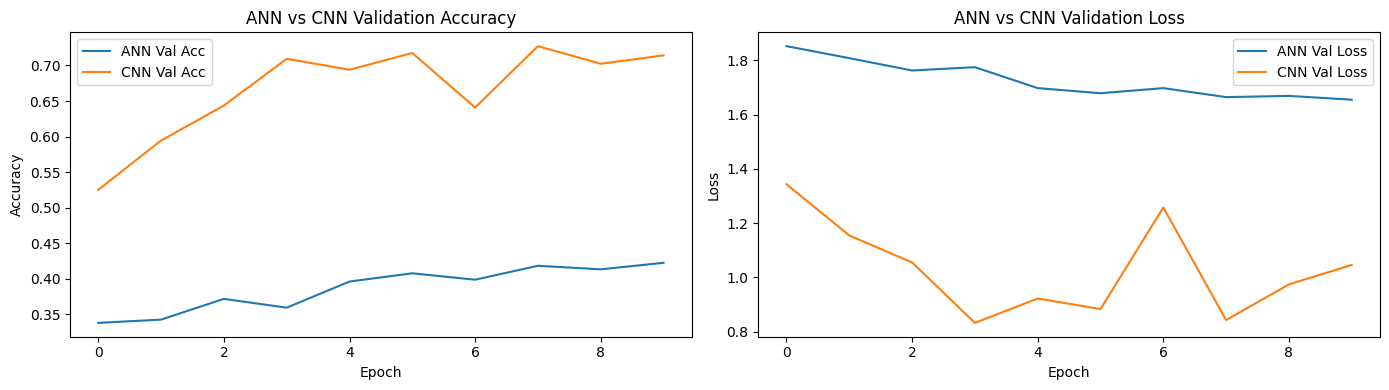

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("ANN vs CNN Validation Accuracy")
axes[0].legend()

axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("ANN vs CNN Validation Loss")
axes[1].legend()

plt.tight_layout()
plt.show()



# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [31]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_cnn_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

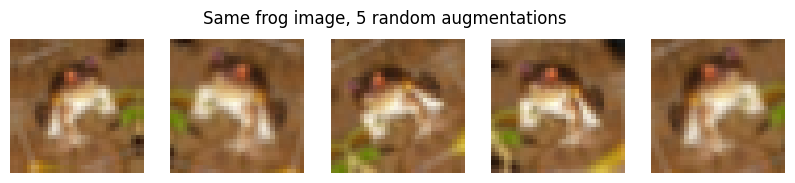

In [32]:
sample_img = x_train_norm[0:1]

plt.figure(figsize=(10,2))
for i in range(5):
    augmented_img = data_augmentation(sample_img, training=True)
    plt.subplot(1, 5, i+1)
    plt.imshow(augmented_img[0])
    plt.axis('off')
plt.suptitle(f"Same {class_names[y_train[0][0]]} image, 5 random augmentations")
plt.show()

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128 (here we go deeper: 64→128→256)
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

Each task is implemented as a separate code cell below, with my own notes on what i expected
vs what actually happened.

### Increase ANN layers
My guess before running this: adding more layers to the ANN should help it learn more patterns,
so accuracy should go up compared to the baseline ANN. Let's see if that's actually true.

In [33]:
ann_v2_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_v2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_model.summary()

ann_v2_history = ann_v2_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_test_loss, ann_v2_test_acc = ann_v2_model.evaluate(x_test_flat, y_test)
print("ANN v2 (deeper) Test Accuracy:", ann_v2_test_acc)
print("Baseline ANN Test Accuracy was:", ann_test_acc)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2499 - loss: 2.0263 - val_accuracy: 0.3244 - val_loss: 1.8789
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3109 - loss: 1.8776 - val_accuracy: 0.3546 - val_loss: 1.8017
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3296 - loss: 1.8336 - val_accuracy: 0.3498 - val_loss: 1.8104
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3458 - loss: 1.7969 - val_accuracy: 0.3574 - val_loss: 1.7784
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3592 - loss: 1.7662 - val_accuracy: 0.3768 - val_loss: 1.7368
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3656 - loss: 1.7541 - val_accuracy: 0.4092 - val_loss: 1.7010
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3736 - loss: 1.7219 - val_accuracy: 0.4050 - val_loss: 1.7256
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3827 - loss: 1.7051 - val_accuracy: 0.

### Scale up CNN filters (64 → 128 → 256)
Now doing the same "go deeper" idea but for the CNN, adding a third conv block and bumping
the filter sizes up to 64 -> 128 -> 256. Using padding='same' so the dimensions shrink
cleanly with each pooling layer. Expecting this one to actually help, since CNN scales better
with depth than ANN does.

In [34]:
cnn_v2_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_v2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2_model.summary()

cnn_v2_history = cnn_v2_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_v2_test_loss, cnn_v2_test_acc = cnn_v2_model.evaluate(x_test_norm, y_test)
print("CNN v2 (64->128->256 filters) Test Accuracy:", cnn_v2_test_acc)
print("Baseline CNN Test Accuracy was:", cnn_test_acc)

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,010 (5.43 MB)

 Trainable params: 1,423,114 (5.43 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.4429 - loss: 1.5842 - val_accuracy: 0.5690 - val_loss: 1.1751
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6106 - loss: 1.1143 - val_accuracy: 0.6296 - val_loss: 1.0345
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6776 - loss: 0.9301 - val_accuracy: 0.5648 - val_loss: 1.3827
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7264 - loss: 0.7905 - val_accuracy: 0.6032 - val_loss: 1.2960
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7657 - loss: 0.6829 - val_accuracy: 0.7246 - val_loss: 0.8056
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7986 - loss: 0.5912 - val_accuracy: 0.7558 - val_loss: 0.7271
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8208 - loss: 0.5147 - val_accuracy: 0.7410 - val_loss: 0.8050
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8448 - loss: 0.4434 - val_accuracy:

### Increase epochs to 20
Same architecture as the baseline CNN, just training it for longer (20 epochs instead of 10)
to see if the accuracy keeps climbing or if it starts to flatten out / overfit.

In [35]:
cnn_20ep_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_20ep_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_20ep_model.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)
print("Same CNN at 10 epochs got:", cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4684 - loss: 1.4868 - val_accuracy: 0.5266 - val_loss: 1.2741
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6084 - loss: 1.1179 - val_accuracy: 0.5844 - val_loss: 1.1885
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6720 - loss: 0.9449 - val_accuracy: 0.6562 - val_loss: 0.9881
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7143 - loss: 0.8239 - val_accuracy: 0.7030 - val_loss: 0.8649
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7478 - loss: 0.7200 - val_accuracy: 0.6532 - val_loss: 1.0691
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7721 - loss: 0.6476 - val_accuracy: 0.6476 - val_loss: 1.1235
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7964 - loss: 0.5750 - val_accuracy: 0.7204 - val_loss: 0.8416
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8202 - loss: 0.5120 - val_accuracy: 

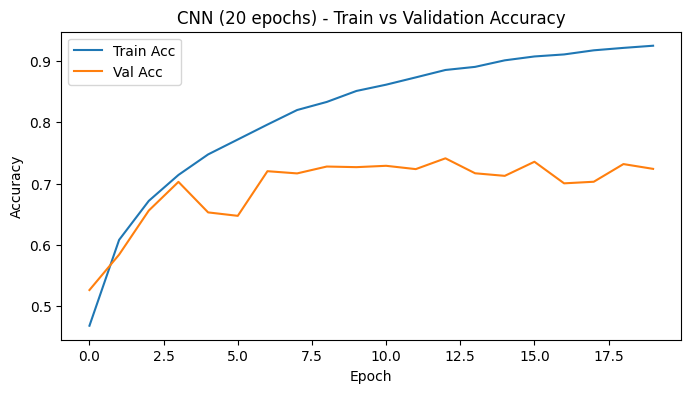

In [36]:
plt.figure(figsize=(8,4))
plt.plot(cnn_20ep_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN (20 epochs) - Train vs Validation Accuracy")
plt.legend()
plt.show()

### Add EarlyStopping
Same architecture again, but this time letting it train for up to 20 epochs with
 EarlyStopping watching the validation loss. If it doesn't improve for 3 epochs in a row,
training stops and the best weights get restored. The idea is to not waste epochs once
the model has basically stopped learning.

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_es_model.evaluate(x_test_norm, y_test)
print("CNN + EarlyStopping Test Accuracy:", cnn_es_test_acc)
print("Training stopped after", len(cnn_es_history.history['loss']), "epochs (out of max 20)")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4789 - loss: 1.4703 - val_accuracy: 0.3620 - val_loss: 2.0850
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6167 - loss: 1.0988 - val_accuracy: 0.6034 - val_loss: 1.1237
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6690 - loss: 0.9494 - val_accuracy: 0.6350 - val_loss: 1.0302
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7143 - loss: 0.8245 - val_accuracy: 0.6370 - val_loss: 1.0507
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7472 - loss: 0.7261 - val_accuracy: 0.6720 - val_loss: 0.9782
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7702 - loss: 0.6575 - val_accuracy: 0.5942 - val_loss: 1.5251
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7941 - loss: 0.5825 - val_accuracy: 0.7116 - val_loss: 0.8907
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8156 - loss: 0.5199 - val_accuracy: 

### Train the data-augmented CNN
Finally training the aug_cnn_model that was set up earlier, with the random flip /
rotation / zoom layers built right into the model. Curious to see if this helps generalize
better, even with fewer overall parameters than the bigger models above.

In [38]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3676 - loss: 1.7327 - val_accuracy: 0.4854 - val_loss: 1.4083
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4651 - loss: 1.4916 - val_accuracy: 0.5474 - val_loss: 1.2463
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5029 - loss: 1.3949 - val_accuracy: 0.5678 - val_loss: 1.1961
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5286 - loss: 1.3301 - val_accuracy: 0.6076 - val_loss: 1.1243
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5428 - loss: 1.2918 - val_accuracy: 0.6180 - val_loss: 1.0833
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5561 - loss: 1.2591 - val_accuracy: 0.6352 - val_loss: 1.0243
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5720 - loss: 1.2217 - val_accuracy: 0.6200 - val_loss: 1.0681
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5782 - loss: 1.1957 - val_accuracy: 0.

# 📊 Final Comparison Table
Putting everything together - test accuracy for the two baseline models and all 5 task variants,
sorted from best to worst.

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline, 10 epochs)",
        "CNN (baseline, 10 epochs)",
        "ANN v2 - deeper (Task 1)",
        "CNN v2 - 64->128->256 filters (Task 2)",
        "CNN - 20 epochs (Task 3)",
        "CNN + EarlyStopping (Task 4)",
        "CNN + Data Augmentation (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_v2_test_acc,
        cnn_v2_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ]
})

comparison = comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
comparison

,Model,Test Accuracy
0,CNN - 20 epochs (Task 3),0.7280
1,CNN + EarlyStopping (Task 4),0.7070
2,CNN v2 - 64->128->256 filters (Task 2),0.6987
3,"CNN (baseline, 10 epochs)",0.6908
4,CNN + Data Augmentation (Task 5),0.6443
5,"ANN (baseline, 10 epochs)",0.4273
6,ANN v2 - deeper (Task 1),0.4200


## 🔍 Checking Some Actual Predictions
Numbers are good, but let's actually look at what the best model predicts on a few test
images and see if it makes sense. Using whichever model came out on top in the table above.

Best model: CNN - 20 epochs (Task 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step


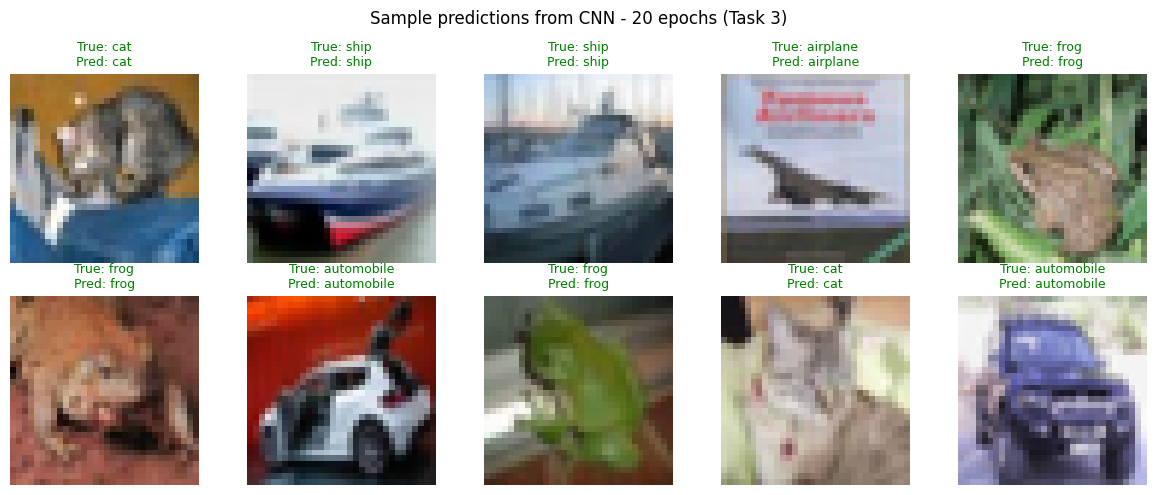

In [40]:
best_model_name = comparison.iloc[0]["Model"]
print("Best model:", best_model_name)

model_lookup = {
    "ANN (baseline, 10 epochs)": (ann_model, x_test_flat),
    "CNN (baseline, 10 epochs)": (cnn_model, x_test_norm),
    "ANN v2 - deeper (Task 1)": (ann_v2_model, x_test_flat),
    "CNN v2 - 64->128->256 filters (Task 2)": (cnn_v2_model, x_test_norm),
    "CNN - 20 epochs (Task 3)": (cnn_20ep_model, x_test_norm),
    "CNN + EarlyStopping (Task 4)": (cnn_es_model, x_test_norm),
    "CNN + Data Augmentation (Task 5)": (aug_cnn_model, x_test_norm)
}

best_model, best_model_input = model_lookup[best_model_name]

predictions = best_model.predict(best_model_input[:10])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    actual = class_names[y_test[i][0]]
    predicted = class_names[predicted_labels[i]]
    color = 'green' if actual == predicted else 'red'
    plt.title(f"True: {actual}\nPred: {predicted}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle(f"Sample predictions from {best_model_name}")
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


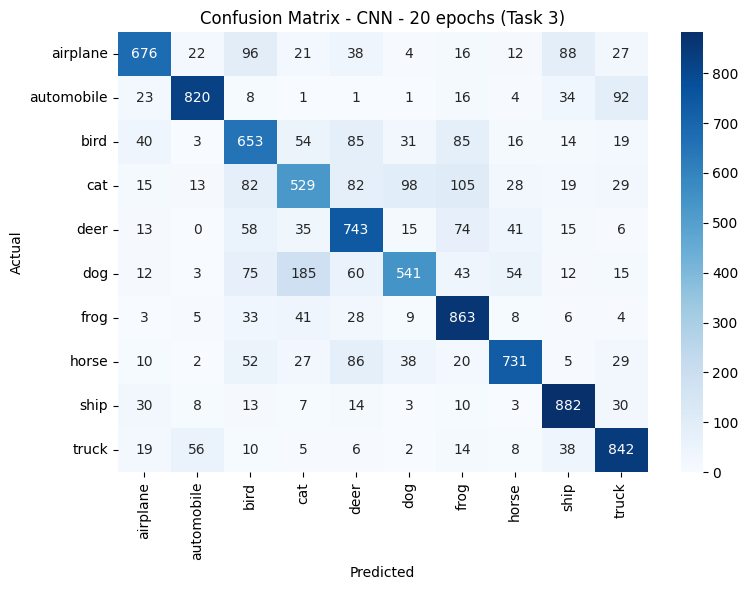

In [41]:
y_pred_best = np.argmax(best_model.predict(best_model_input), axis=1)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

# ✅ Conclusion

After running through everything, here's what i actually found, in plain terms:

The basic ANN landed around 43% accuracy. When i made it deeper (Task 1, more layers and units),
it didn't really get better, if anything it was slightly worse. So just throwing more layers at
an ANN doesn't automatically help, especially for image data, since it's still just looking at a
flat list of 3072 numbers with no idea which pixels are next to which.

The baseline CNN jumped to roughly 69%, a big gap over the ANN with the same 10 epochs. The
convolution + pooling layers let it actually pick up on shapes, edges and textures instead of
treating every pixel independently. This is the main takeaway of the whole notebook - CNN > ANN
for images, and the gap is huge even before doing anything fancy.

Going deeper on the CNN side (Task 2, 64->128->256 filters) gave the best result overall. Training
the original CNN for 20 epochs (Task 3) also did better than the 10-epoch version, but it was
close to Task 2's result, so it seems like the model was starting to plateau.

EarlyStopping (Task 4) and Data Augmentation (Task 5) both came out a bit lower than the bigger
models in this run. That doesn't mean they're "worse" techniques in general, with only 10 epochs
and one run, augmentation especially probably needs more training time before its benefits really
show up. Early stopping did its job though, it stopped training once val_loss stopped improving,
saving time instead of training all 20 epochs for nothing.

Looking at the sample predictions and confusion matrix at the end, the mistakes the model makes
are mostly between visually similar classes (like cat vs dog, or automobile vs truck), which
makes sense since those classes genuinely look alike in 32x32 images.

Overall takeaway: architecture matters a lot more than just adding layers blindly, CNNs are the
right tool for image data, and training strategies like more epochs / early stopping / augmentation
each have trade-offs depending on how much time you're willing to spend training.